In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
#Load CSV Dataset
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")


In [4]:
#Convert everything to numeric
train_df = train_df.apply(pd.to_numeric, errors='coerce')
test_df = test_df.apply(pd.to_numeric, errors='coerce')

In [5]:
# Replace NaN values with 0
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

In [6]:
X = train_df.drop("label", axis=1).values.astype("float32")
y = train_df["label"].values.astype("int32")


In [7]:
X_test = test_df.drop("label", axis=1).values.astype("float32")
y_test = test_df["label"].values.astype("int32")

In [8]:
#Normalize (0–255 → 0–1)
X = X / 255.0
X_test = X_test / 255.0

In [9]:
# 6. Reshape for CNN
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [10]:
print("Any NaN in X:", np.isnan(X).any())
print("Any NaN in y:", np.isnan(y).any())

Any NaN in X: False
Any NaN in y: False


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)


In [12]:
# 9. Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# 10. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)


Epoch 1/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.8132 - loss: 0.5171 - val_accuracy: 0.8677 - val_loss: 0.3678
Epoch 2/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.8743 - loss: 0.3468 - val_accuracy: 0.8819 - val_loss: 0.3279
Epoch 3/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.8905 - loss: 0.2994 - val_accuracy: 0.8972 - val_loss: 0.2889
Epoch 4/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.9022 - loss: 0.2676 - val_accuracy: 0.8982 - val_loss: 0.2846
Epoch 5/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9109 - loss: 0.2380 - val_accuracy: 0.9018 - val_loss: 0.2735
Epoch 6/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.9193 - loss: 0.2166 - val_accuracy: 0.9041 - val_loss: 0.2673
Epoch 7/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 76s 60ms/step - accuracy: 0.9277 - loss: 0.1947 - val_accuracy: 0.9100 - val_loss: 0.2637
Epoch 8/10
692/692 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9339 - loss: 0.1780 - 

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\n✅ Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9142 - loss: 0.2501

✅ Test Accuracy: 0.9142000079154968


In [17]:
predictions = model.predict(X_test)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [16]:
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


In [22]:
predictions = model.predict(X_test)



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


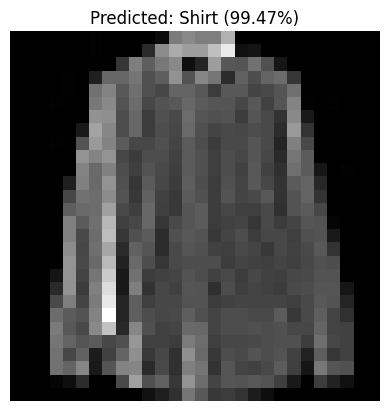

In [26]:
index = 89
plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]} ({np.max(predictions[index]) * 100:.2f}%)")
plt.axis('off')
plt.show()